In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/Yazid/Desktop/USPN/Projet/sample_system_dataset_1.csv")  
df.head()


,Unnamed: 0,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,0,2,2,1970-01-06,05:37:22,inspection,NaN,125.62,125.62,125.62,NaN,100,100
1,1,3,3,1970-01-06,12:49:35,inspection,NaN,132.83,132.83,132.83,NaN,100,100
2,2,8,8,1970-01-06,22:43:37,inspection,NaN,142.73,142.73,142.73,NaN,100,100
3,3,5,5,1970-01-07,04:28:22,inspection,NaN,148.47,148.47,148.47,NaN,100,100
4,4,6,6,1970-01-07,06:10:21,inspection,NaN,150.17,150.17,150.17,NaN,100,100


In [2]:
df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                10000 non-null  int64  
 1   system_id                 10000 non-null  int64  
 2   component_id              10000 non-null  int64  
 3   event_date                10000 non-null  object 
 4   event_time                10000 non-null  object 
 5   event_type                10000 non-null  object 
 6   event_report              2789 non-null   object 
 7   system_age                10000 non-null  float64
 8   component_age             10000 non-null  float64
 9   usage_since_last_event_h  10000 non-null  float64
 10  FF                        607 non-null    object 
 11  cost_event                10000 non-null  int64  
 12  cost_cumulated            10000 non-null  int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 1015.8+ KB


,Unnamed: 0,system_id,component_id,event_date,event_time,event_type,event_report,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
count,10000.00000,10000.000000,10000.00000,10000,10000,10000,2789,10000.000000,10000.000000,10000.000000,607,10000.000000,10000.000000
unique,NaN,NaN,NaN,3976,8244,3,4,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,NaN,1981-09-02,10:17:53,inspection,unused,NaN,NaN,NaN,True,NaN,NaN
freq,NaN,NaN,NaN,10,5,6686,1899,NaN,NaN,NaN,484,NaN,NaN
mean,4999.50000,5.498400,950.38020,NaN,NaN,NaN,NaN,56466.045449,419.275416,112.321084,NaN,443.090000,219970.200000
std,2886.89568,2.879762,549.82065,NaN,NaN,NaN,NaN,32447.605711,221.041801,71.864958,NaN,488.372914,128373.629507
min,0.00000,1.000000,1.00000,NaN,NaN,NaN,NaN,125.620000,0.110000,0.000000,NaN,100.000000,100.000000
25%,2499.75000,3.000000,474.75000,NaN,NaN,NaN,NaN,28330.282500,230.290000,32.707500,NaN,100.000000,108900.000000
50%,4999.50000,5.000000,950.00000,NaN,NaN,NaN,NaN,56614.500000,422.445000,140.385000,NaN,100.000000,218350.000000
75%,7499.25000,8.000000,1426.00000,NaN,NaN,NaN,NaN,84653.407500,605.227500,170.010000,NaN,1100.000000,330400.000000


In [3]:
df['event_type'].value_counts(normalize=True)


event_type
inspection     0.6686
replacement    0.2022
failure        0.1292
Name: proportion, dtype: float64

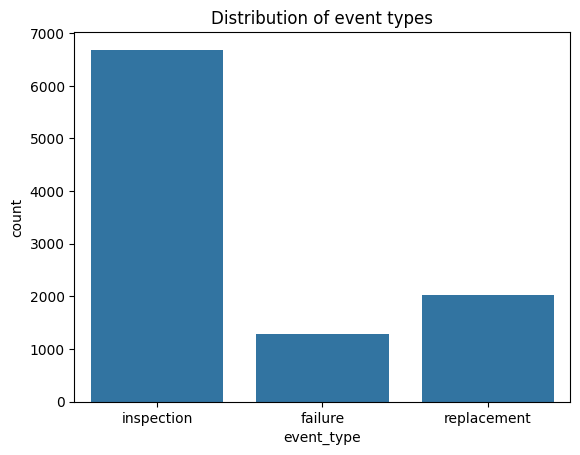

In [4]:
sns.countplot(data=df, x="event_type")
plt.title("Distribution of event types")
plt.show()

In [5]:
df['event_date'] = pd.to_datetime(df['event_date'])

df.groupby("event_type")['event_date'].min(), df.groupby("event_type")['event_date'].max()


(event_type
 failure       1970-01-11
 inspection    1970-01-06
 replacement   1970-01-11
 Name: event_date, dtype: datetime64[ns],
 event_type
 failure       1982-10-28
 inspection    1982-10-28
 replacement   1982-10-27
 Name: event_date, dtype: datetime64[ns])

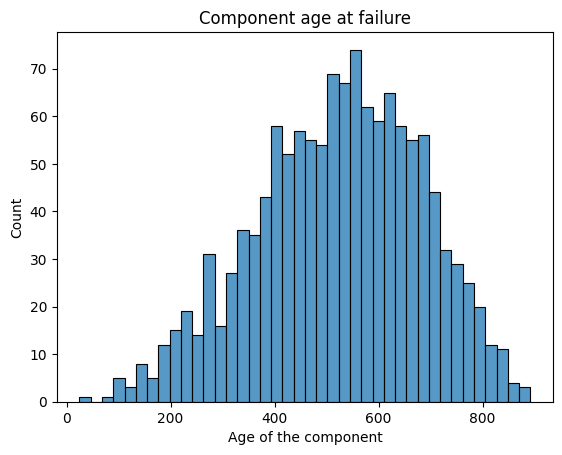

In [6]:
failures = df[df.event_type == "failure"]

sns.histplot(failures['component_age'], bins=40)
plt.title("Component age at failure")
plt.xlabel("Age of the component")
plt.show()

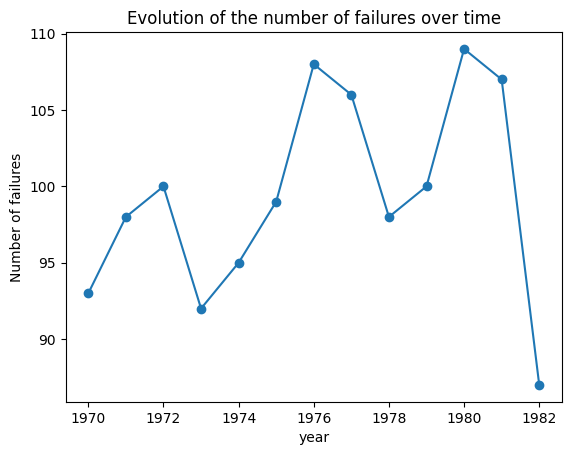

In [7]:
df['year'] = df['event_date'].dt.year

failure_rate = df[df.event_type == "failure"].groupby("year").size()
failure_rate.plot(kind="line", marker="o")
plt.title("Evolution of the number of failures over time")
plt.ylabel("Number of failures")
plt.show()


In [8]:
# Creates a boolean variable
# True if the event is an inspection, False otherwise
df['is_inspection'] = df.event_type == "inspection"

# Computes the average age
df.groupby("is_inspection")['component_age'].mean()

is_inspection
False    564.080232
True     347.501087
Name: component_age, dtype: float64

* True : Mean age of component at the inspection
* False :Mean age of component : Replacement / Failure

In average, the componenents involved in inspection are significantly younger than component involved in failures or replacement.

This indicates that the inspections detect components earlier, therefore, reducing the risks.

In [9]:
df['FF'].value_counts(dropna=False)

FF
NaN      9393
True      484
False     123
Name: count, dtype: int64

In [10]:
df[df.FF == True].event_type.value_counts()

event_type
replacement    484
Name: count, dtype: int64

In [11]:
df.groupby("event_type")['cost_event'].mean()

event_type
failure        1200.000000
inspection      100.000000
replacement    1093.916914
Name: cost_event, dtype: float64

In average :

* Inspection event have the lowest cost.
* Failures ar the most expensive.



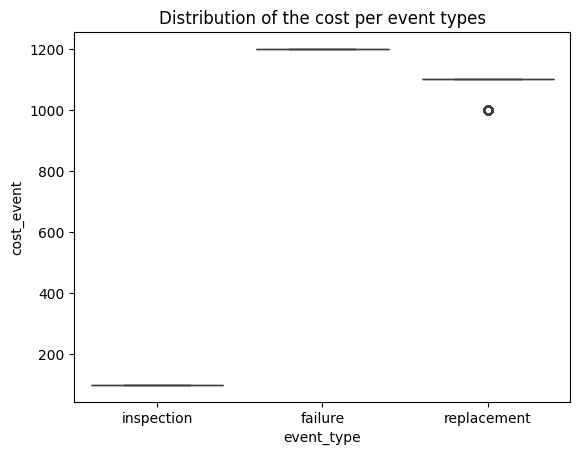

In [12]:
sns.boxplot(data=df, x="event_type", y="cost_event")
plt.title("Distribution of the cost per event types")
plt.show()

In [13]:
cost_system = df.groupby("system_id")['cost_cumulated'].max()

cost_system.describe()

count        10.000000
mean     443090.000000
std       13674.343372
min      421100.000000
25%      434550.000000
50%      445700.000000
75%      453550.000000
max      460300.000000
Name: cost_cumulated, dtype: float64

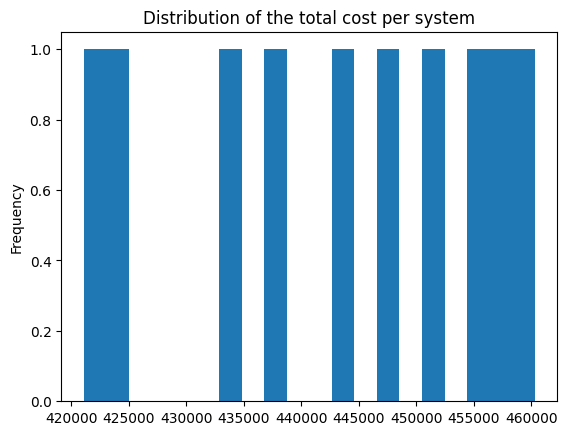

In [14]:
cost_system.plot(kind="hist", bins=20)
plt.title("Distribution of the total cost per system")
plt.show()

In [15]:
# Number of failure per month
failures = df[df.event_type == "failure"].copy()
failures['month'] = failures['event_date'].dt.to_period("M")

monthly_failures = failures.groupby("month").size()
monthly_failures.describe()

count    154.000000
mean       8.389610
std        2.368949
min        1.000000
25%        7.000000
50%        8.000000
75%       10.000000
max       16.000000
dtype: float64

The number of failures per month shows a significant variablity.

This variablity reflects both the nature of component degradation, and the failure of inspection.

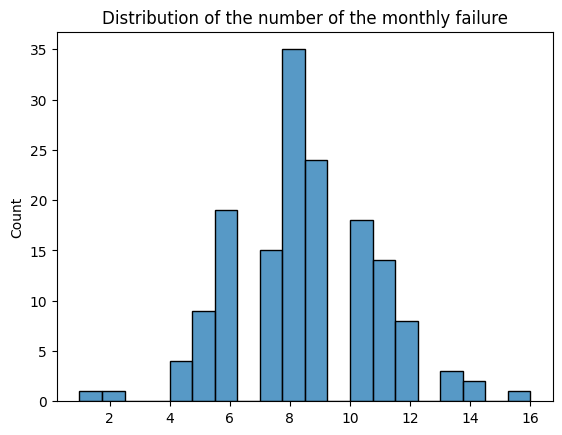

In [16]:
sns.histplot(monthly_failures, bins=20)
plt.title("Distribution of the number of the monthly failure")
plt.show()

In [17]:
# Intervalle de confiance empirique de "failure"
q_low, q_high = np.percentile(monthly_failures, [2.5, 97.5])
q_low, q_high

(4.0, 13.0)

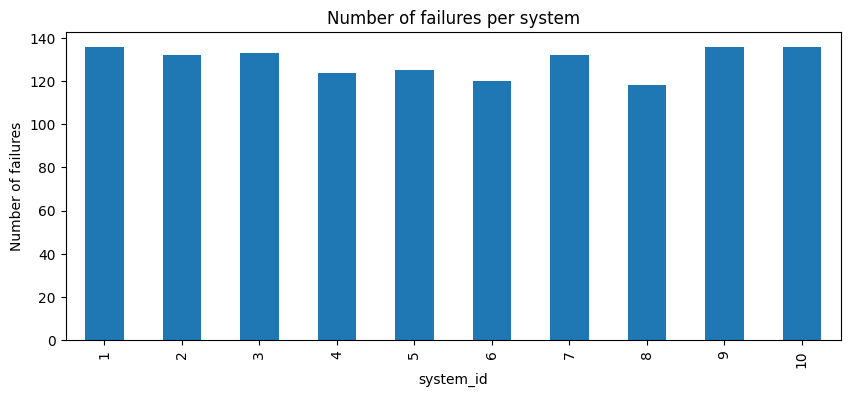

In [18]:
failures_per_system = (
    df[df.event_type == "failure"]
    .groupby("system_id")
    .size()
)

failures_per_system.plot(kind="bar", figsize=(10,4))
plt.title("Number of failures per system")
plt.ylabel("Number of failures")
plt.show()


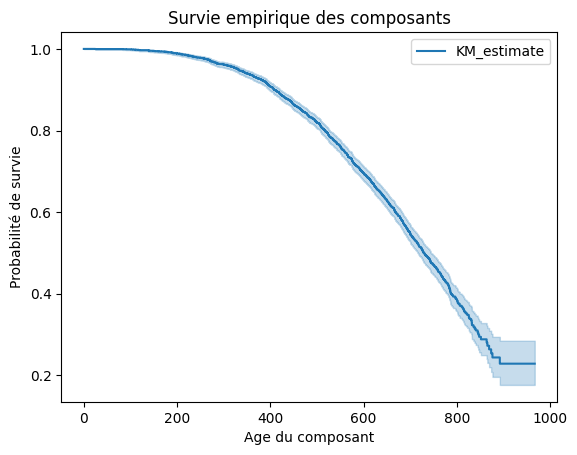

In [19]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

failures = df[df.event_type.isin(["failure", "replacement"])].copy()
failures["event"] = failures.event_type == "failure"

kmf.fit(
    durations=failures["component_age"],
    event_observed=failures["event"]
)

kmf.plot_survival_function()
plt.title("Survie empirique des composants")
plt.xlabel("Age du composant")
plt.ylabel("Probabilité de survie")
plt.show()


C:\Users\Yazid\AppData\Local\Temp\ipykernel_6236\2919638463.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fail["age_bin"] = pd.cut(df_fail["component_age"], bins)
C:\Users\Yazid\AppData\Local\Temp\ipykernel_6236\2919638463.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hazard = df_fail.groupby("age_bin").size()


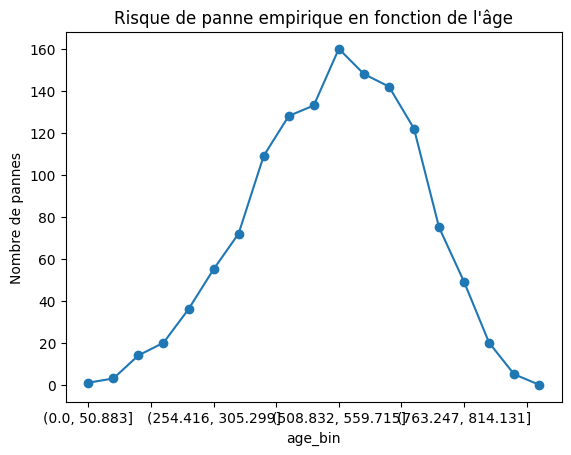

In [20]:
df_fail = df[df.event_type == "failure"]

bins = np.linspace(0, df.component_age.max(), 20)
df_fail["age_bin"] = pd.cut(df_fail["component_age"], bins)

hazard = df_fail.groupby("age_bin").size()
hazard.plot(kind="line", marker="o")
plt.title("Risque de panne empirique en fonction de l'âge")
plt.ylabel("Nombre de pannes")
plt.show()


In [21]:
df.groupby("event_report")["event_type"].value_counts()

event_report  event_type 
expired       inspection      104
reused        replacement     123
unused        replacement    1899
wornout       inspection      663
Name: count, dtype: int64

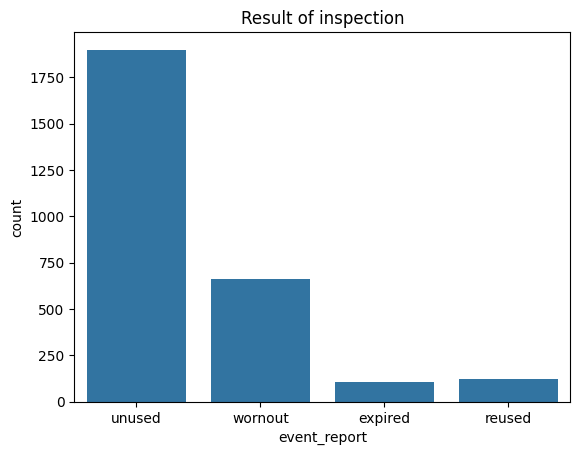

In [22]:
sns.countplot(data=df, x="event_report")
plt.title("Result of inspection")
plt.show()


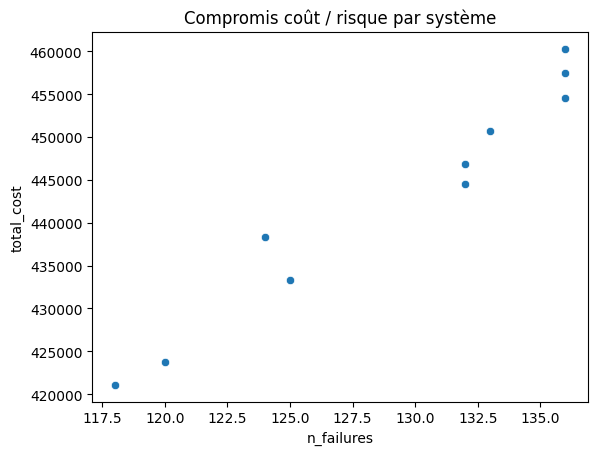

In [23]:
system_summary = df.groupby("system_id").agg(
    total_cost=("cost_cumulated", "max"),
    n_failures=("event_type", lambda x: (x=="failure").sum())
)

sns.scatterplot(
    data=system_summary,
    x="n_failures",
    y="total_cost"
)
plt.title("Compromis coût / risque par système")
plt.show()